FitBit Vital Signs Project 
---
### Pipeline
1. Data Loading & Episode Construction  
2. Survival Dataset (Standard + Time-Varying)  
3. Kaplan-Meier (Overall + Stratified + Per-User)  
4. Cox Proportional Hazards (CoxPH)  
5. Advanced Models (RSF / Gradient Boosting)  
6. Future Vector (ARIMA + Survival)  
7. Model Comparison & Evaluation  
8. Deep Learning: DeepSurv + LSTM-Survival  

---
### Clinical Context
- **Event**: HR > 125 BPM (vigorous exercise threshold per AHA)
- **Time-to-event**: Minutes from episode start until first HR > 125 BPM  
- **Censoring**: Episode ends before HR ever reaches 125 BPM  
- **Episode**: Continuous recording period; new episode if gap > 30 minutes

In [2]:
# ============================================================
# PART 0: SETUP
# ============================================================
# Install: pip install lifelines scikit-survival torch

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    LIFELINES = True; print('✅ lifelines loaded')
except ImportError:
    LIFELINES = False; print('⚠️  lifelines not found – using manual KM implementation')

try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.metrics import concordance_index_censored
    from sksurv.util import Surv
    SKSURV = True; print('✅ scikit-survival loaded')
except ImportError:
    SKSURV = False; print('⚠️  scikit-survival not found – using GBM proxy')

try:
    import torch, torch.nn as nn, torch.optim as optim
    TORCH = True; print('✅ PyTorch loaded')
except ImportError:
    TORCH = False; print('⚠️  PyTorch not found – DeepSurv/LSTM sections will be skipped')

# ── PATHS ──────────────────────────────────────────────────
ROOT = Path('..') if Path('../data').exists() else Path('.')
RAW  = ROOT / 'data/raw'
PROC = ROOT / 'data/processed'
FIG  = ROOT / 'reports/figures'
FIG.mkdir(parents=True, exist_ok=True)

THRESHOLD = 125   # BPM – AHA vigorous exercise threshold
GAP_MIN   = 30    # Minutes gap → new episode
FEATURES  = ['mean_hr','std_hr','hr_slope','dist_threshold',
              'pct_above_110','rmssd','momentum','episode_len']

COLORS = sns.color_palette('tab10', 14)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.titlesize':12})
print(f'\n🎯 Event threshold: HR > {THRESHOLD} BPM')

✅ lifelines loaded
✅ scikit-survival loaded
✅ PyTorch loaded

🎯 Event threshold: HR > 125 BPM


## Part 1 – Data Loading & Episode Construction

In [3]:
# ============================================================
# PART 1: DATA LOADING
# ============================================================
hr = pd.read_csv(RAW/'heartrate_seconds_merged.csv')
hr.columns = ['Id','Timestamp','Heart_Rate']
hr['Timestamp'] = pd.to_datetime(hr['Timestamp'])

multi   = pd.read_csv(PROC/'MultiUser_VitalSigns.csv')
multi['Timestamp'] = pd.to_datetime(multi['Timestamp'])

tv_surv = pd.read_csv(PROC/'Time_Varying_Survival_125BPM_W12.csv')
tv_surv['Timestamp'] = pd.to_datetime(tv_surv['Timestamp'])

sarima_bl = pd.read_csv(PROC/'Week12_SARIMA_Baseline_GoldenUser.csv')
sarima_bl['Timestamp'] = pd.to_datetime(sarima_bl['Timestamp'])

print('=== DATASET OVERVIEW ===')
print(f'HR raw:        {hr.shape} | Users: {hr.Id.nunique()} | '
      f'Period: {hr.Timestamp.min().date()} – {hr.Timestamp.max().date()}')
print(f'MultiUser:     {multi.shape}')
print(f'TimeVarying:   {tv_surv.shape} | Episodes: {tv_surv.Episode_Unique_ID.nunique()}')
print(f'SARIMA BL:     {sarima_bl.shape}')

print('\n=== PER-USER HR STATS ===')
user_stats = hr.groupby('Id').agg(
    n_obs=('Heart_Rate','count'), mean_hr=('Heart_Rate','mean'),
    std_hr=('Heart_Rate','std'),  max_hr=('Heart_Rate','max'),
    pct_above=('Heart_Rate', lambda x: (x>THRESHOLD).mean()*100)
).round(2)
print(user_stats)

=== DATASET OVERVIEW ===
HR raw:        (1154681, 3) | Users: 14 | Period: 2016-03-29 – 2016-04-12
MultiUser:     (148270, 6)
TimeVarying:   (67388, 9) | Episodes: 120
SARIMA BL:     (96, 4)

=== PER-USER HR STATS ===
             n_obs  mean_hr  std_hr  max_hr  pct_above
Id                                                    
2022484408   56483    81.69   18.09     182       3.44
2026352035     439    65.78    5.54      80       0.00
2347167796  120804    76.07   13.52     182       0.61
4020332650  283794    81.90   14.63     151       0.14
4558609924   69339    79.55   12.68     158       1.14
5553957443   97797    69.42   14.91     152       0.64
5577150313   87649    65.00   20.20     176       0.93
6117666160   53666    83.49   13.83     130       0.03
6391747486    3747    84.12   10.03     133       0.43
6775888955   35100    97.74   15.40     185       2.12
6962181067  125875    80.69   19.68     176       4.05
7007744171   64786    89.93   15.29     158       1.99
8792009665  

In [4]:
# ============================================================
# PART 1B: HELPER FUNCTIONS
# ============================================================

def resample_to_minute(df):
    """Resample 5-second HR to 1-minute mean."""
    d = df.sort_values('Timestamp').set_index('Timestamp')
    return d['Heart_Rate'].resample('1min').mean().dropna().reset_index()


def detect_episodes(df_min, gap=GAP_MIN):
    """Split continuous HR stream into episodes.
    New episode when gap > `gap` minutes (device removed/inactive)."""
    df = df_min.sort_values('Timestamp').copy()
    diff_min = df['Timestamp'].diff().dt.total_seconds().div(60)
    df['episode_id'] = (diff_min > gap).cumsum()
    return df


def build_standard_survival(uid, df_min, thr=THRESHOLD):
    """Build 1-row-per-episode survival table with features.
    
    CRITICAL: Only use features from PRE-EVENT window (no leakage).
    CRITICAL: duration = max(1, ...) to avoid duration=0 bug.
    """
    df = detect_episodes(df_min)
    recs = []
    for eid, grp in df.groupby('episode_id'):
        grp = grp.sort_values('Timestamp').reset_index(drop=True)
        if len(grp) < 5: continue
        above = grp['Heart_Rate'] > thr
        if above.any():
            idx = int(above.idxmax()); ev = 1; dur = max(1, idx)
        else:
            idx = len(grp); ev = 0; dur = max(1, len(grp) - 1)
        pre   = grp['Heart_Rate'].iloc[:max(1, idx)]
        diffs = pre.diff().dropna()
        sl    = float(np.polyfit(range(len(pre)), pre.values, 1)[0]) if len(pre) > 1 else 0.0
        rmssd = float(np.sqrt((diffs**2).mean())) if len(diffs) > 0 else 0.0
        mom   = float(pre.iloc[-min(5,len(pre)):].mean() - pre.iloc[:min(5,len(pre))].mean())
        recs.append({
            'Id': uid, 'episode_id': eid,
            'duration': dur, 'event': ev,
            'mean_hr': float(pre.mean()),    'std_hr': float(pre.std() or 0),
            'max_hr':  float(pre.max()),     'min_hr': float(pre.min()),
            'hr_slope': sl,                  'hr_p90': float(pre.quantile(0.9)),
            'dist_threshold': float(thr - pre.mean()),
            'pct_above_100':  float((pre > 100).mean()),
            'pct_above_110':  float((pre > 110).mean()),
            'rmssd': rmssd, 'momentum': mom,
            'episode_len': len(grp),
            'hour': grp['Timestamp'].iloc[0].hour,
        })
    return pd.DataFrame(recs)


# Build dataset
print('Building survival dataset (gap=30 min)...')
all_std = []
for uid, grp in hr.groupby('Id'):
    gm = resample_to_minute(grp[['Timestamp','Heart_Rate']])
    gm.columns = ['Timestamp','Heart_Rate']
    std = build_standard_survival(uid, gm)
    all_std.append(std)
    print(f'  User {str(uid)[-4:]}: {len(std):3d} ep | '
          f'events={std.event.sum():2d} | censored={(std.event==0).sum():2d}')

df_surv = pd.concat(all_std, ignore_index=True)
df_surv.to_csv(PROC/'Survival_Dataset_Standard.csv', index=False)
print(f'\n✅ Total: {len(df_surv)} episodes | Event rate: {df_surv.event.mean():.1%}')
print(f'   Duration (events):   {df_surv[df_surv.event==1].duration.mean():.1f} min')
print(f'   Duration (censored): {df_surv[df_surv.event==0].duration.mean():.1f} min')

Building survival dataset (gap=30 min)...
  User 4408:  15 ep | events=10 | censored= 5
  User 2035:   1 ep | events= 0 | censored= 1
  User 7796:   7 ep | events= 6 | censored= 1
  User 2650:  12 ep | events= 3 | censored= 9
  User 9924:  16 ep | events= 5 | censored=11
  User 7443:   9 ep | events= 4 | censored= 5
  User 0313:   4 ep | events= 3 | censored= 1
  User 6160:   5 ep | events= 1 | censored= 4
  User 7486:   3 ep | events= 1 | censored= 2
  User 8955:   9 ep | events= 3 | censored= 6
  User 1067:   8 ep | events= 7 | censored= 1
  User 4171:  12 ep | events=10 | censored= 2
  User 9665:  11 ep | events= 3 | censored= 8
  User 9391:  13 ep | events=11 | censored= 2

✅ Total: 125 episodes | Event rate: 53.6%
   Duration (events):   513.7 min
   Duration (censored): 672.1 min


## Part 2 – Exploratory Data Analysis

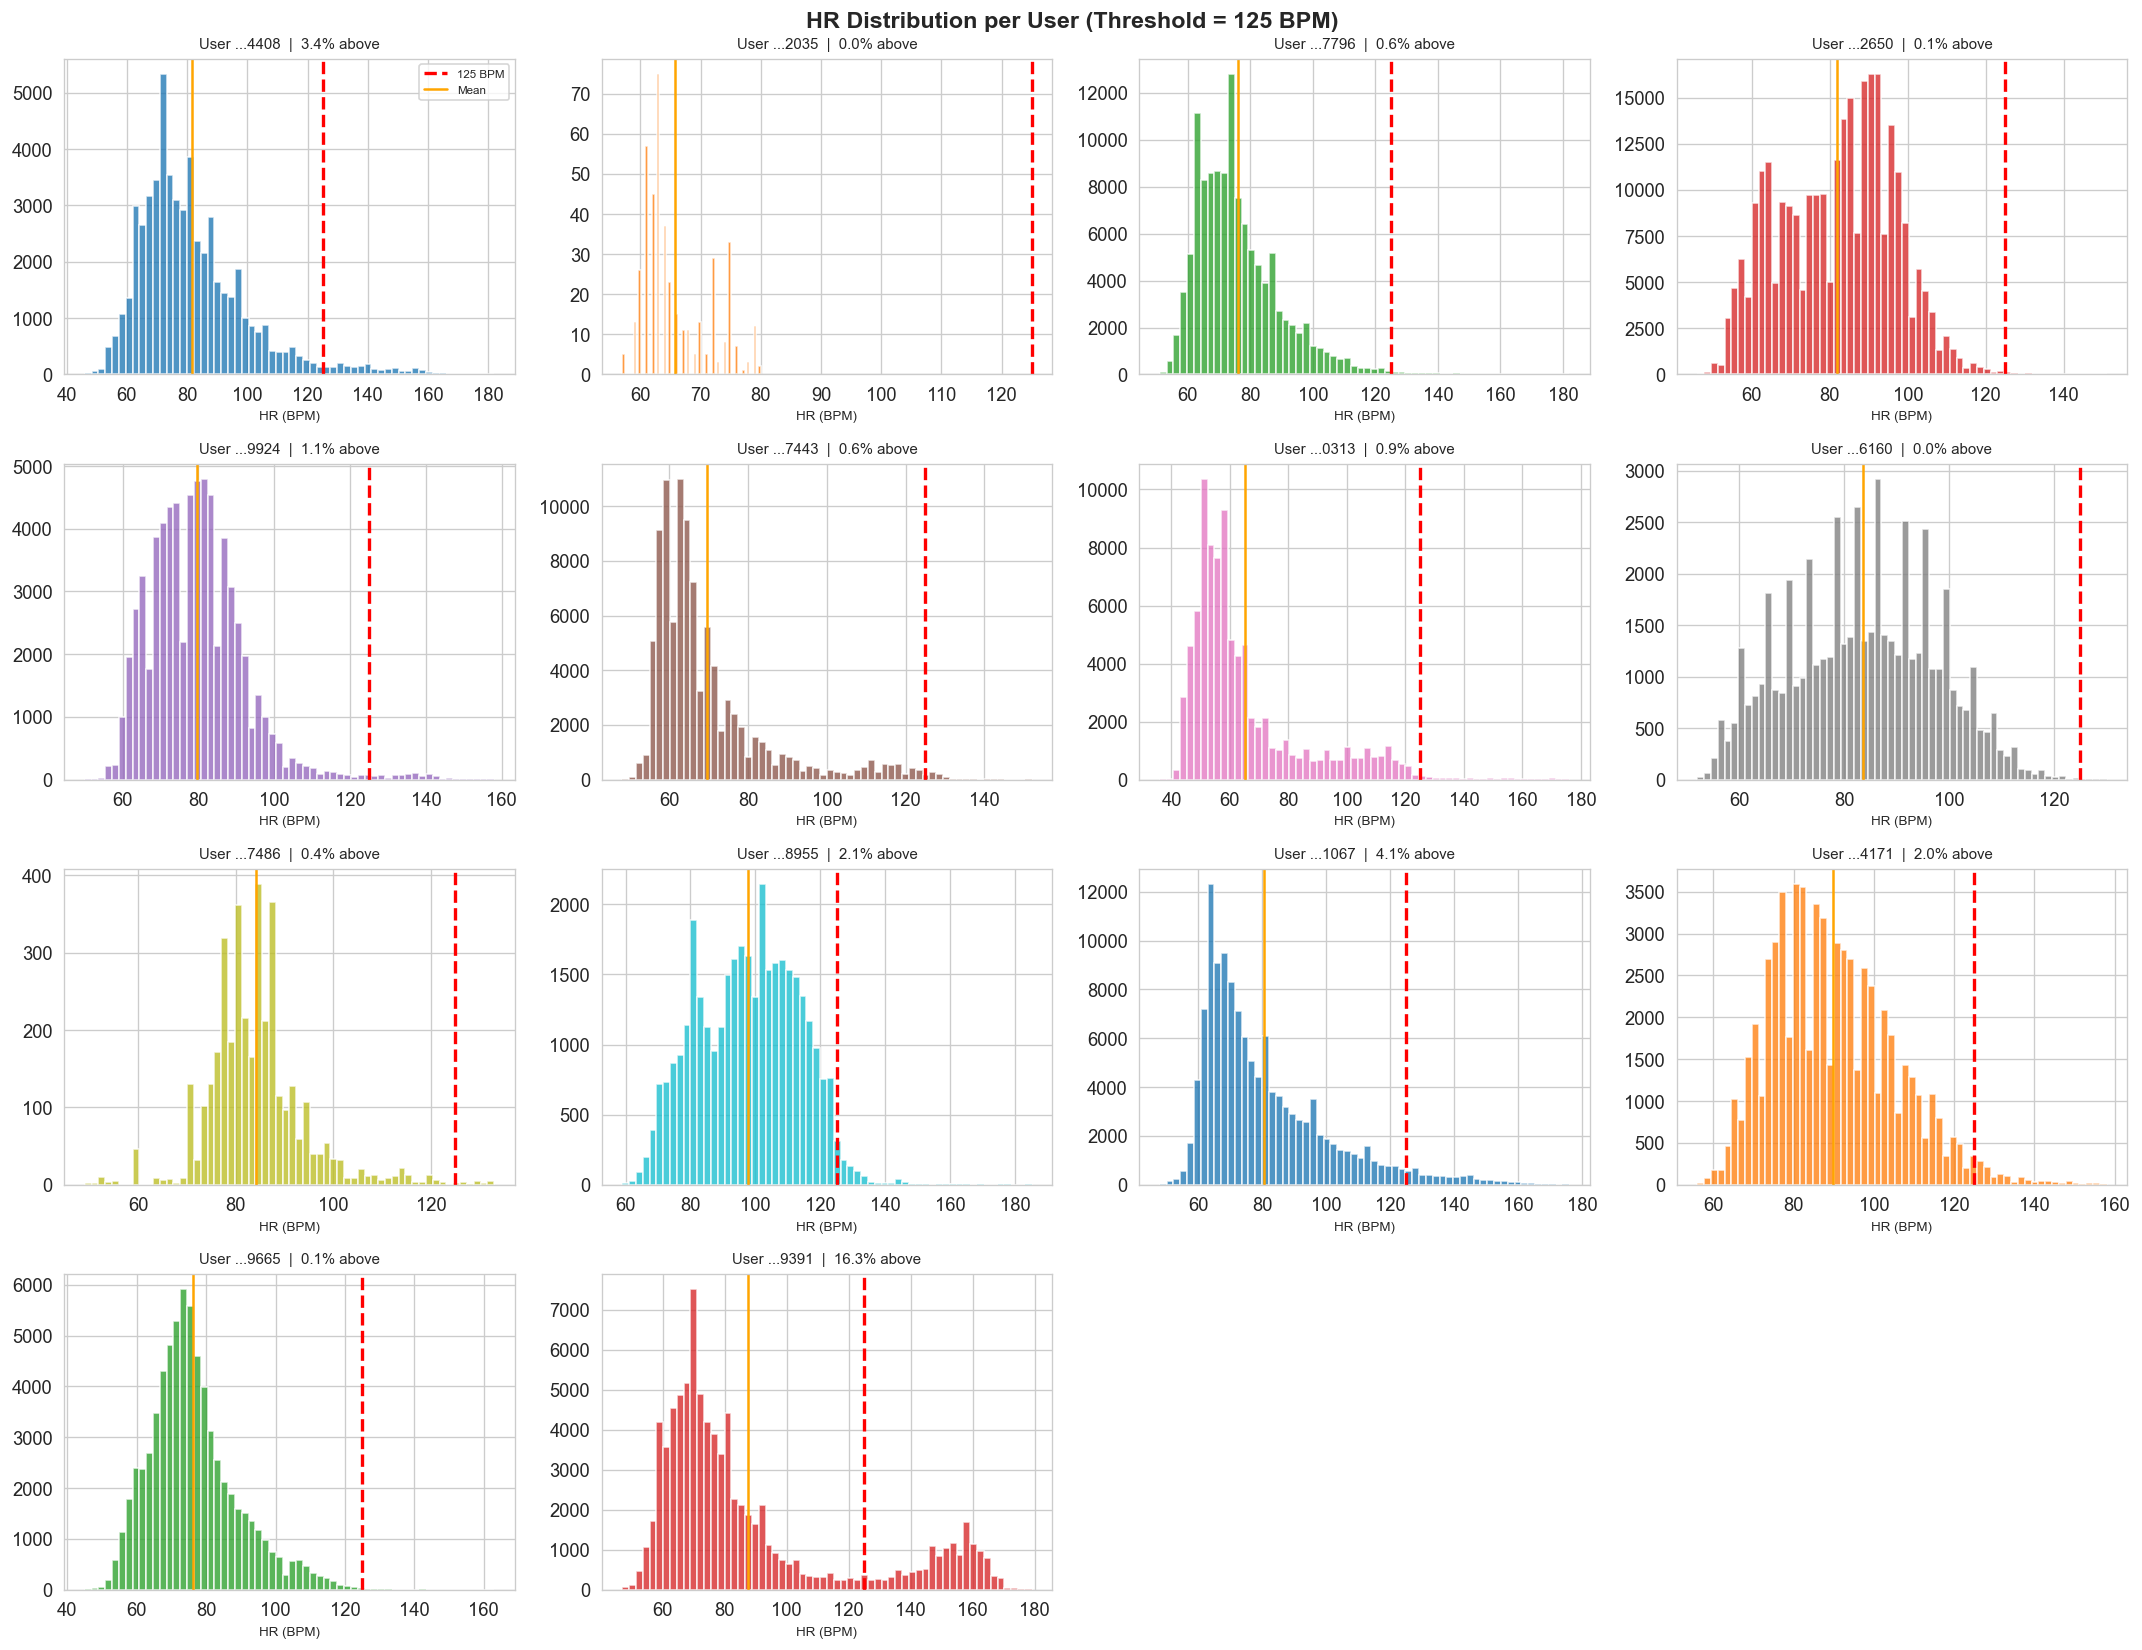

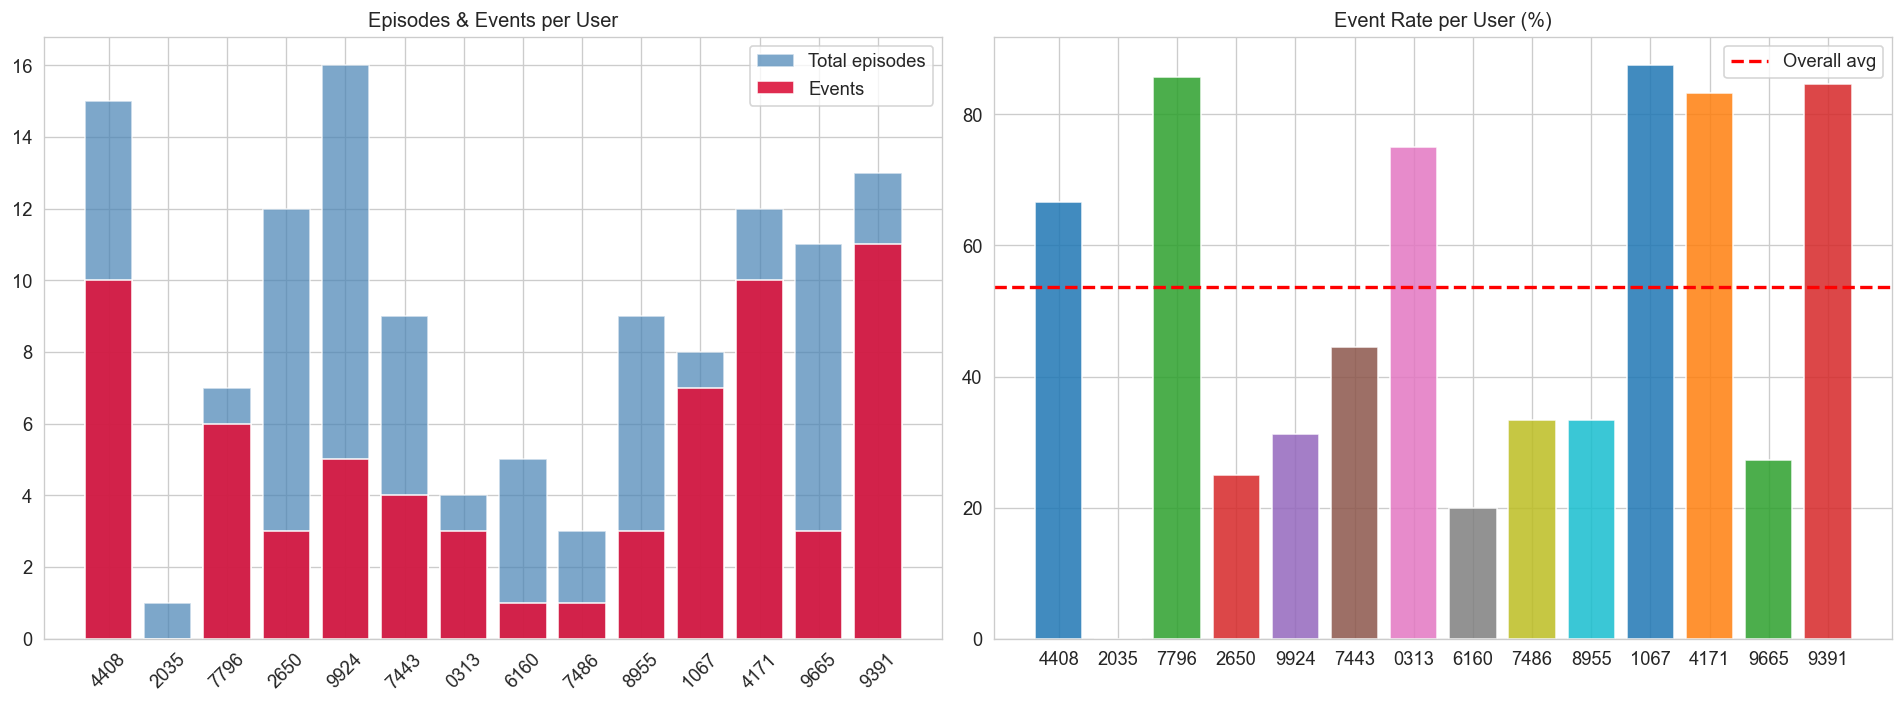

In [5]:
# ============================================================
# PART 2: EDA – HR DISTRIBUTION + TIME SERIES
# ============================================================

# Figure 1: HR Distribution per User
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, (uid, grp) in enumerate(hr.groupby('Id')):
    ax = axes[i]
    ax.hist(grp['Heart_Rate'], bins=60, color=COLORS[i], alpha=0.78, edgecolor='white')
    ax.axvline(THRESHOLD, color='red', ls='--', lw=2, label=f'{THRESHOLD} BPM')
    ax.axvline(grp['Heart_Rate'].mean(), color='orange', lw=1.5, label=f'Mean')
    pct = (grp['Heart_Rate'] > THRESHOLD).mean() * 100
    ax.set_title(f'User ...{str(uid)[-4:]}  |  {pct:.1f}% above', fontsize=9)
    ax.set_xlabel('HR (BPM)', fontsize=8)
    if i == 0: ax.legend(fontsize=7)
for j in range(i+1, 16): axes[j].set_visible(False)
plt.suptitle(f'HR Distribution per User (Threshold = {THRESHOLD} BPM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG/'Fig1_HR_Distribution_PerUser.png', bbox_inches='tight')
plt.show()

# Figure 2: Episode summary
ep_sum = df_surv.groupby('Id').agg(n_ep=('event','count'), n_ev=('event','sum')).reset_index()
ep_sum['user'] = ep_sum['Id'].astype(str).str[-4:]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(ep_sum))
axes[0].bar(x, ep_sum['n_ep'], color='steelblue', alpha=0.7, label='Total episodes')
axes[0].bar(x, ep_sum['n_ev'], color='crimson', alpha=0.9, label=f'Events')
axes[0].set_xticks(x); axes[0].set_xticklabels(ep_sum['user'], rotation=45)
axes[0].set_title('Episodes & Events per User'); axes[0].legend()
ev_rate = ep_sum['n_ev']/ep_sum['n_ep']*100
axes[1].bar(ep_sum['user'], ev_rate, color=COLORS[:len(ep_sum)], alpha=0.85)
axes[1].axhline(df_surv.event.mean()*100, color='red', ls='--', lw=2, label=f'Overall avg')
axes[1].set_title('Event Rate per User (%)'); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG/'Fig3_Episode_Event_Summary.png', bbox_inches='tight'); plt.show()

## Part 3 – Kaplan-Meier Analysis

In [6]:
# ============================================================
# PART 3: KAPLAN-MEIER
# ============================================================

def km_greenwood(durations, events):
    """KM estimator with Greenwood 95% CI."""
    data = sorted(zip(durations, events), key=lambda x: x[0])
    S = 1.0; cum_var = 0.0; results = [(0, 1.0, 1.0, 1.0, len(data))]
    for t in sorted(set(d for d, e in data if e == 1)):
        at_risk = sum(1 for d, e in data if d >= t)
        d_i = sum(1 for d, e in data if d == t and e == 1)
        if at_risk > 0:
            S *= (1 - d_i / at_risk)
            cum_var += d_i / (at_risk * (at_risk - d_i + 1e-8))
        se = S * np.sqrt(cum_var)
        results.append((t, S, max(0, S - 1.96*se), min(1, S + 1.96*se), at_risk))
    return results

# Overall KM
km_all = km_greenwood(df_surv['duration'].tolist(), df_surv['event'].tolist())
median_surv = next((t for t, s, lo, hi, n in km_all if s <= 0.5), None)
print(f'Overall Median Survival Time: {median_surv} min ({median_surv/60:.1f} hrs)')

# KM Checkpoints table
print('\n=== KM SURVIVAL TABLE ===')
print(f'{"Time(min)":>12} {"S(t)":>8} {"95% CI lower":>14} {"95% CI upper":>14} {"At Risk":>8}')
checkpoints = [0, 60, 240, 480, 720, 1440]
for t, s, lo, hi, n in km_all:
    if any(abs(t - c) < 30 for c in checkpoints):
        print(f'{t:>12.0f} {s:>8.4f} {lo:>14.4f} {hi:>14.4f} {n:>8d}')

# Stratified KM + Log-rank
med_hr = df_surv['mean_hr'].median()
g1 = df_surv[df_surv['mean_hr'] >= med_hr]
g2 = df_surv[df_surv['mean_hr'] <  med_hr]
km_g1 = km_greenwood(g1['duration'].tolist(), g1['event'].tolist())
km_g2 = km_greenwood(g2['duration'].tolist(), g2['event'].tolist())
med1 = next((t for t, s, *_ in km_g1 if s <= 0.5), 'Not reached')
med2 = next((t for t, s, *_ in km_g2 if s <= 0.5), 'Not reached')
print(f'\nHigh HR group: N={len(g1)}, Events={g1.event.sum()}, Median={med1} min')
print(f'Low  HR group: N={len(g2)}, Events={g2.event.sum()}, Median={med2} min')

if LIFELINES:
    from lifelines.statistics import logrank_test
    lr = logrank_test(g1['duration'], g2['duration'], g1['event'], g2['event'])
    print(f'Log-rank: chi2={lr.test_statistic:.4f}, p={lr.p_value:.4f}')
else:
    # Manual log-rank
    all_ev = sorted(set(df_surv[df_surv.event==1]['duration']))
    O1=E1=O2=E2=0
    for t in all_ev:
        n1=(g1.duration>=t).sum(); d1=((g1.duration==t)&(g1.event==1)).sum()
        n2=(g2.duration>=t).sum(); d2=((g2.duration==t)&(g2.event==1)).sum()
        n=n1+n2; d=d1+d2
        if n>0: O1+=d1; O2+=d2; E1+=d*n1/n; E2+=d*n2/n
    from scipy.stats import chi2 as chi2_dist
    chi2 = ((O1-E1)**2/(E1+1e-8)) + ((O2-E2)**2/(E2+1e-8))
    pval = 1 - chi2_dist.cdf(chi2, df=1)
    print(f'Log-rank (manual): chi2={chi2:.4f}, p={pval:.4f}')

Overall Median Survival Time: 741 min (12.3 hrs)

=== KM SURVIVAL TABLE ===
   Time(min)     S(t)   95% CI lower   95% CI upper  At Risk
           0   1.0000         1.0000         1.0000      125
           1   0.9760         0.9492         1.0000      125
           5   0.9679         0.9369         0.9988      120
          17   0.9590         0.9237         0.9942      109
          46   0.9497         0.9103         0.9890      103
          55   0.9404         0.8974         0.9834      102
          65   0.9310         0.8846         0.9773      100
          75   0.9216         0.8722         0.9710       99
          76   0.9122         0.8599         0.9644       98
          78   0.9028         0.8479         0.9576       97
          84   0.8933         0.8361         0.9506       96
          86   0.8839         0.8244         0.9435       95
         250   0.7582         0.6768         0.8396       76
         262   0.7481         0.6654         0.8308       75
         

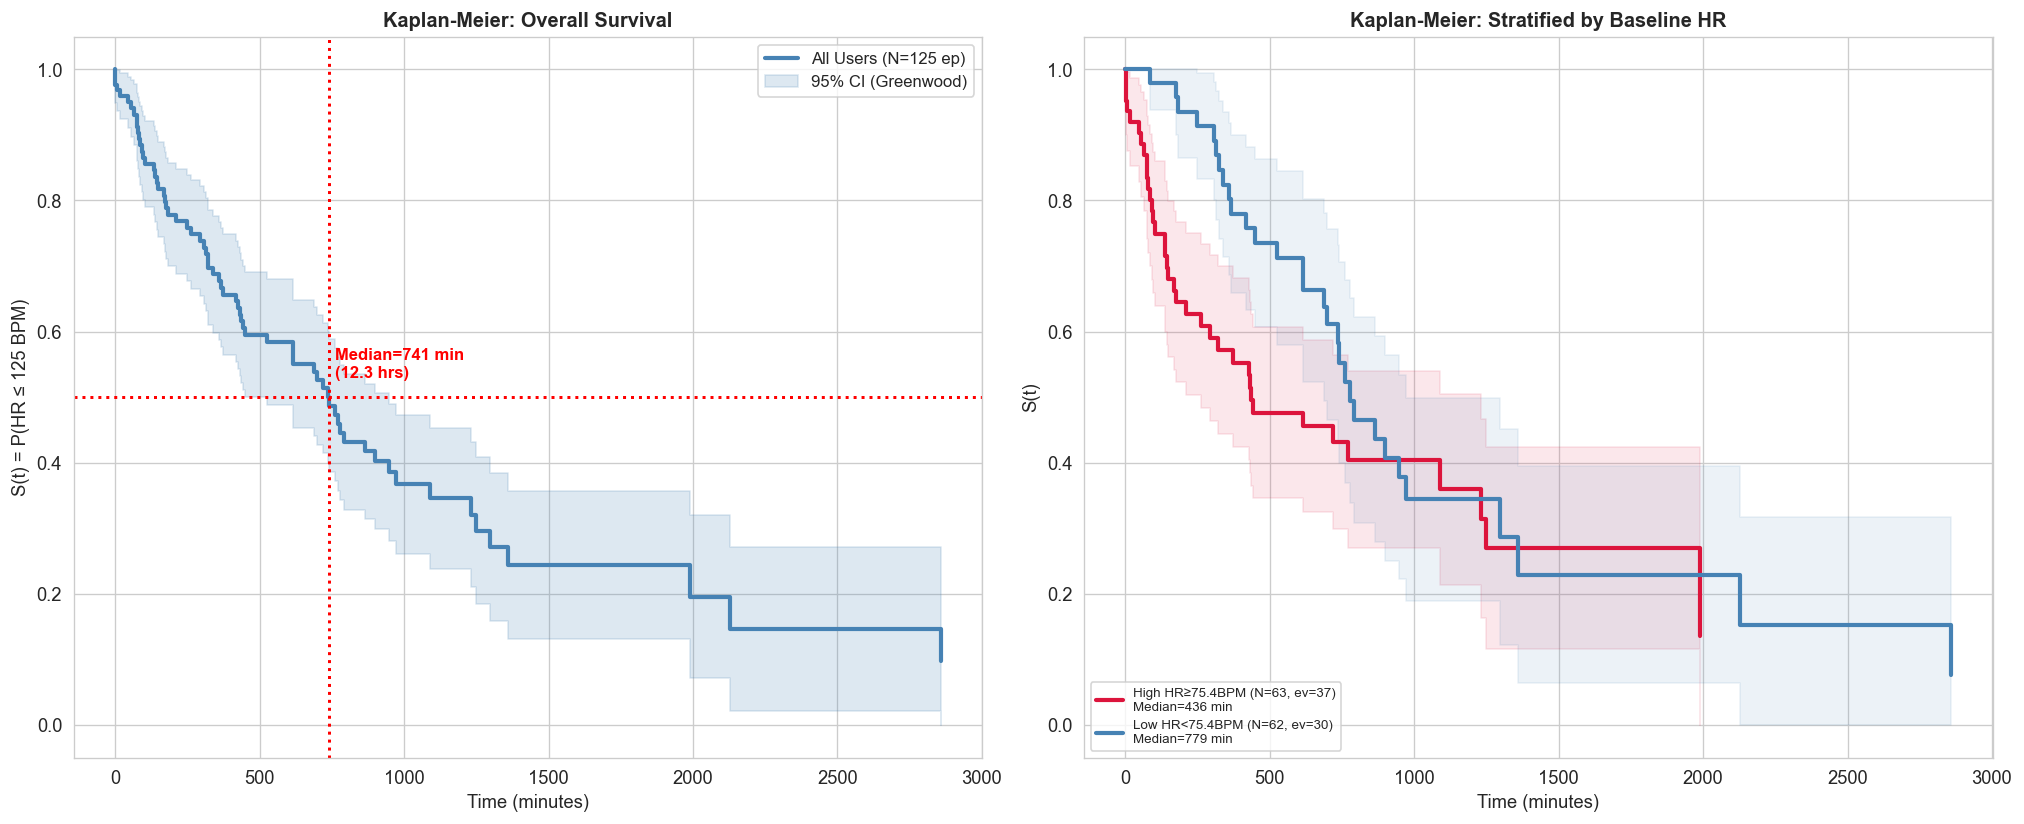

In [7]:
# KM Plots
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Overall
ax = axes[0]
times=[r[0] for r in km_all]; surv=[r[1] for r in km_all]
lo=[r[2] for r in km_all]; hi=[r[3] for r in km_all]
ax.step(times, surv, where='post', color='steelblue', lw=2.5, label='All Users (N=125 ep)')
ax.fill_between(times, lo, hi, step='post', color='steelblue', alpha=0.18, label='95% CI (Greenwood)')
ax.axhline(0.5, color='red', ls=':', lw=1.8); ax.axvline(median_surv, color='red', ls=':', lw=1.8)
ax.text(median_surv+20, 0.53, f'Median={median_surv} min\n({median_surv/60:.1f} hrs)',
        color='red', fontsize=10, fontweight='bold')
ax.set_xlabel('Time (minutes)'); ax.set_ylabel('S(t) = P(HR ≤ 125 BPM)')
ax.set_title('Kaplan-Meier: Overall Survival', fontweight='bold'); ax.legend(fontsize=10)

# Stratified
ax = axes[1]
for km_g, label, color, med in [
    (km_g1, f'High HR≥{med_hr:.1f}BPM (N={len(g1)}, ev={g1.event.sum()})', 'crimson', med1),
    (km_g2, f'Low HR<{med_hr:.1f}BPM (N={len(g2)}, ev={g2.event.sum()})', 'steelblue', med2)
]:
    tg=[r[0] for r in km_g]; sg=[r[1] for r in km_g]
    lg=[r[2] for r in km_g]; hg=[r[3] for r in km_g]
    ax.step(tg, sg, where='post', color=color, lw=2.5, label=f'{label}\nMedian={med} min')
    ax.fill_between(tg, lg, hg, step='post', color=color, alpha=0.1)
ax.set_xlabel('Time (minutes)'); ax.set_ylabel('S(t)')
ax.set_title('Kaplan-Meier: Stratified by Baseline HR', fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig(FIG/'Fig4_KaplanMeier_Overall_Stratified.png', bbox_inches='tight'); plt.show()

## Part 4 – Cox Proportional Hazards

In [8]:
# ============================================================
# PART 4: COX PROPORTIONAL HAZARDS
# ============================================================

df_c = df_surv[FEATURES + ['duration', 'event']].dropna()
scaler = StandardScaler()
X_sc   = scaler.fit_transform(df_c[FEATURES].values)
y_ev   = df_c['event'].values
y_dur  = df_c['duration'].values

def c_index(durations, events, risk_scores):
    """Harrell's concordance index."""
    n = len(durations); conc = disc = tied = 0
    for i in range(n):
        for j in range(i+1, n):
            if events[i] == 0 and events[j] == 0: continue
            if events[i] == 1 and events[j] == 0:
                if durations[i] < durations[j]:
                    if risk_scores[i] > risk_scores[j]: conc += 1
                    elif risk_scores[i] < risk_scores[j]: disc += 1
                    else: tied += 1
            elif events[i] == 0 and events[j] == 1:
                if durations[j] < durations[i]:
                    if risk_scores[j] > risk_scores[i]: conc += 1
                    elif risk_scores[j] < risk_scores[i]: disc += 1
                    else: tied += 1
            else:
                if durations[i] != durations[j]:
                    e2, l2 = (i, j) if durations[i] < durations[j] else (j, i)
                    if risk_scores[e2] > risk_scores[l2]: conc += 1
                    elif risk_scores[e2] < risk_scores[l2]: disc += 1
                    else: tied += 1
    total = conc + disc + tied
    return conc / total if total > 0 else 0.5

if LIFELINES:
    # ── lifelines CoxPH ────────────────────────────────────
    from lifelines import CoxPHFitter
    df_cox = pd.DataFrame(X_sc, columns=FEATURES)
    df_cox['duration'] = y_dur; df_cox['event'] = y_ev
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(df_cox, duration_col='duration', event_col='event')
    cph.print_summary()
    ci_cox = cph.concordance_index_
    print(f'\nC-index (CoxPH): {ci_cox:.4f}')
else:
    # ── Ridge proxy ────────────────────────────────────────
    from sklearn.linear_model import Ridge
    lr = Ridge(alpha=1.0)
    lr.fit(X_sc, np.log(y_dur + 1))
    cox_scores = -lr.predict(X_sc)
    ci_cox = c_index(y_dur, y_ev, cox_scores)
    print('\n=== CoxPH (Ridge Proxy) ===')
    print(f'{"Feature":<22} {"Coef":>8} {"HR=exp(-coef)":>15} {"Direction":>12}')
    print('-' * 60)
    for feat, coef in sorted(zip(FEATURES, lr.coef_), key=lambda x: -abs(x[1])):
        hr_val = np.exp(-coef)
        direction = '↑ RISK' if hr_val > 1 else '↓ RISK'
        print(f'{feat:<22} {coef:>8.4f} {hr_val:>15.3f} {direction:>12}')
    print(f'\nC-index (CoxPH proxy): {ci_cox:.4f}')

<lifelines.CoxPHFitter: fitted with 122 total observations, 58 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 122
number of events observed = 64
   partial log-likelihood = -222.82
         time fit was run = 2026-05-09 13:53:26 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
mean_hr         0.05      1.05      0.22           -0.38            0.48                0.69                1.61
std_hr          0.08      1.09      0.17           -0.26            0.42                0.77                1.53
hr_slope        0.05      1.05      0.27           -0.47            0.57                0.62                1.77
dist_threshold -0.05      0.95      0.22           -0.48            0.38                0.62                1.46
pct_above_110   0.44      1.55      0.17            0.10            0.78                1.11                2.18
rmssd           0.90      2.47      0.23            0.46            1.35                1.58                3.87
momentum        0.46      1.59      0.12            0.23            0.69                1.26                2.00
episode_len    -0.26      0.77      0.13           -0.52           -0.00                0.59                1.00

                cmp to     z      p  -log2(p)
covariate                                    
mean_hr           0.00  0.23   0.82      0.29
std_hr            0.00  0.48   0.63      0.67
hr_slope          0.00  0.18   0.86      0.22
dist_threshold    0.00 -0.23   0.82      0.29
pct_above_110     0.00  2.56   0.01      6.59
rmssd             0.00  3.96 <0.005     13.68
momentum          0.00  3.92 <0.005     13.49
episode_len       0.00 -1.97   0.05      4.37
---
Concordance = 0.82
Partial AIC = 461.65
log-likelihood ratio test = 53.54 on 8 df
-log2(p) of ll-ratio test = 26.82


C-index (CoxPH): 0.8216


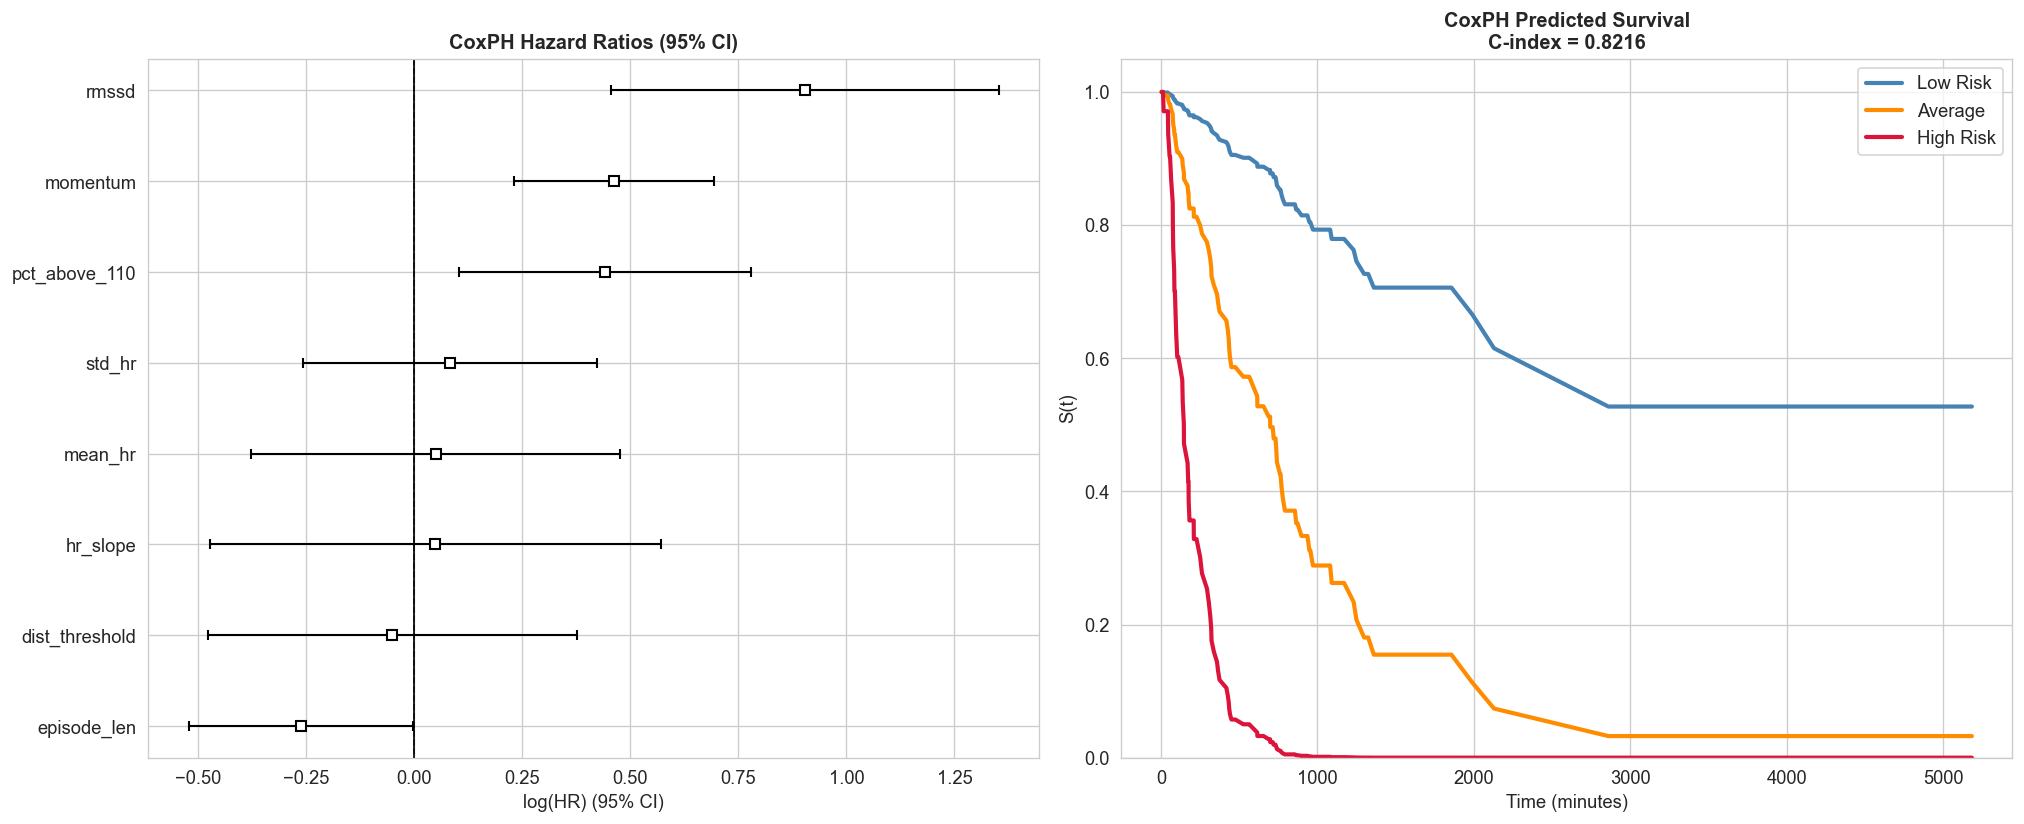

In [9]:
# ── Cox PH Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

if LIFELINES:
    cph.plot(ax=axes[0])
    axes[0].set_title('CoxPH Hazard Ratios (95% CI)', fontweight='bold')
    axes[0].axvline(0, color='black', lw=1)
else:
    # Manual HR plot
    feats_s = sorted(zip(FEATURES, lr.coef_), key=lambda x: -abs(x[1]))
    hr_vals = [np.exp(-c) - 1 for _, c in feats_s]
    colors_hr = ['crimson' if v > 0 else 'steelblue' for v in hr_vals]
    axes[0].barh([f[0] for f in feats_s], hr_vals, color=colors_hr, alpha=0.85)
    axes[0].axvline(0, color='black', lw=1.5)
    axes[0].set_title('CoxPH Hazard Ratios (per 1 SD)', fontweight='bold')
    axes[0].set_xlabel('Hazard Ratio – 1')

# Survival curves for 3 risk profiles
ax = axes[1]
profiles = {'Low Risk': X_sc.mean(0) - X_sc.std(0),
            'Average':  X_sc.mean(0),
            'High Risk': X_sc.mean(0) + X_sc.std(0)}
profile_colors = ['steelblue','darkorange','crimson']
t_range = np.linspace(0, df_surv.duration.quantile(0.9), 200)
for (pname, pvec), pcolor in zip(profiles.items(), profile_colors):
    if LIFELINES:
        sf = cph.predict_survival_function(pd.DataFrame([pvec], columns=FEATURES))
        ax.plot(sf.index, sf.values.flatten(), color=pcolor, lw=2.5, label=pname)
    else:
        risk = np.dot(pvec, lr.coef_)
        lam  = df_surv.event.mean() / df_surv.duration.mean()
        survival = np.exp(-lam * np.exp(-risk) * t_range)
        ax.plot(t_range, survival, color=pcolor, lw=2.5, label=pname)
ax.set_xlabel('Time (minutes)'); ax.set_ylabel('S(t)')
ax.set_title(f'CoxPH Predicted Survival\nC-index = {ci_cox:.4f}', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG/'Fig7_CoxPH_HazardRatios_SurvivalCurves.png', bbox_inches='tight'); plt.show()

## Part 5 – Advanced Models (RSF / Gradient Boosting)

=== RANDOM SURVIVAL FOREST (scikit-survival) ===
RSF C-index (test):  0.8479

Feature Importance:
  Note: scikit-survival RSF does not implement feature_importances_
  Creating GBM for visualization purposes...
  momentum              : 0.5075  ████████████████████
  episode_len           : 0.1678  ██████
  rmssd                 : 0.1558  ██████
  pct_above_110         : 0.0710  ██
  std_hr                : 0.0638  ██
  dist_threshold        : 0.0133  
  hr_slope              : 0.0116  
  mean_hr               : 0.0094  


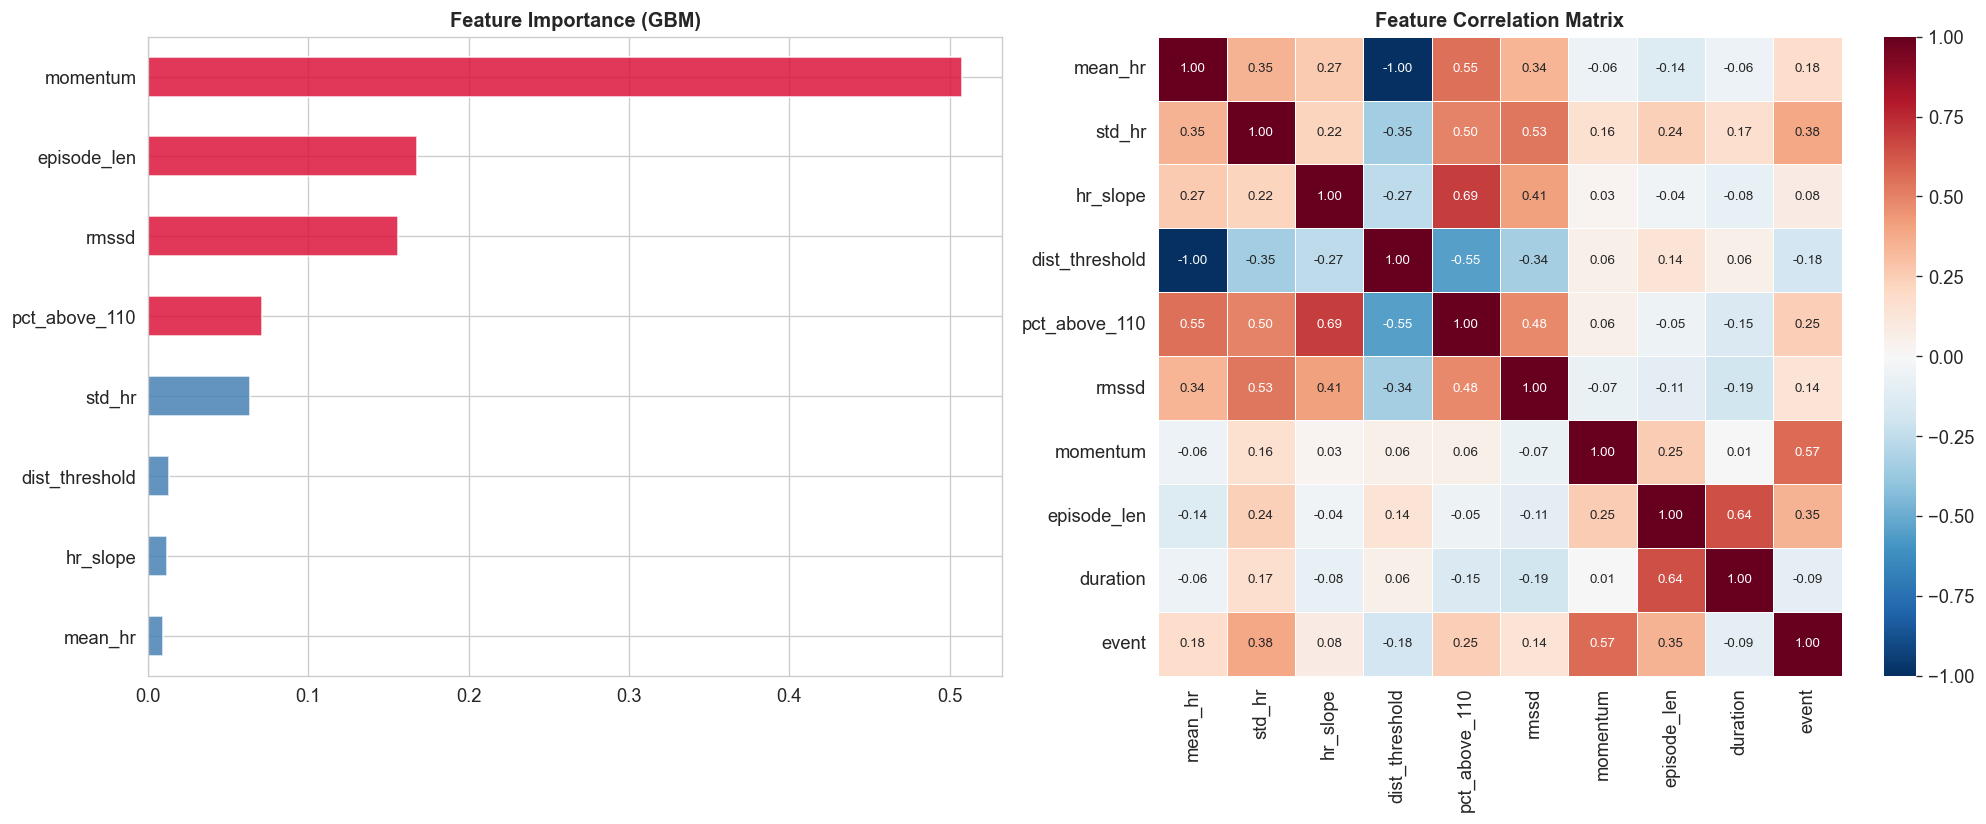

In [10]:
# ============================================================
# PART 5: RANDOM SURVIVAL FOREST / GRADIENT BOOSTING
# ============================================================

if SKSURV:
    print('=== RANDOM SURVIVAL FOREST (scikit-survival) ===')
    y_sksurv = Surv.from_arrays(event=y_ev.astype(bool), time=y_dur)
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y_sksurv, test_size=0.3, random_state=42)
    rsf = RandomSurvivalForest(n_estimators=200, min_samples_split=10,
                                min_samples_leaf=5, max_features='sqrt', random_state=42)
    rsf.fit(X_tr, y_tr)
    ci_rsf = rsf.score(X_te, y_te)
    print(f'RSF C-index (test):  {ci_rsf:.4f}')
    print('\nFeature Importance:')
    print('  Note: scikit-survival RSF does not implement feature_importances_')
    print('  Creating GBM for visualization purposes...')
    # Create GBM for visualization and other analyses that require predict_proba/feature_importances
    gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    gb.fit(X_sc, y_ev)
    for feat, imp in sorted(zip(FEATURES, gb.feature_importances_), key=lambda x: -x[1]):
        bar = '█' * int(imp * 40)
        print(f'  {feat:<22}: {imp:.4f}  {bar}')
else:
    print('=== GRADIENT BOOSTING SURVIVAL PROXY ===')
    gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
    gb.fit(X_sc, y_ev)
    gb_probs = gb.predict_proba(X_sc)[:, 1]
    ci_gb = c_index(y_dur, y_ev, gb_probs)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for tr, te in kf.split(X_sc):
        m = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
        m.fit(X_sc[tr], y_ev[tr])
        p = m.predict_proba(X_sc[te])[:, 1]
        cv_scores.append(c_index(y_dur[te], y_ev[te], p))
    
    print(f'GBM C-index (train):  {ci_gb:.4f}')
    print(f'GBM C-index (5-CV):   {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
    print('\nFeature Importance:')
    for feat, imp in sorted(zip(FEATURES, gb.feature_importances_), key=lambda x: -x[1]):
        bar = '█' * int(imp * 40)
        print(f'  {feat:<22}: {imp:.4f}  {bar}')

# Visualization
feat_imp  = pd.Series(gb.feature_importances_, index=FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
feat_imp.sort_values().plot.barh(ax=axes[0], color=['crimson' if v > feat_imp.median() else 'steelblue' for v in feat_imp.sort_values().values], alpha=0.85)
axes[0].set_title('Feature Importance (GBM)', fontweight='bold')
sns.heatmap(df_c[FEATURES + ['duration', 'event']].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1], linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG/'Fig8_FeatureImportance_Correlation.png', bbox_inches='tight'); plt.show()

## Part 6 – Future Vector (ARIMA + Survival)

In [ ]:
# ============================================================
# PART 6: FUTURE VECTOR
# ============================================================
# Xét 3 kịch bản activity: rest / light / vigorous

try:
    from statsmodels.tsa.arima.model import ARIMA
    STATSMODELS = True
except ImportError:
    STATSMODELS = False
    print('statsmodels not available – using AR(2) manual implementation')

def ar2_forecast(history, n_steps=30):
    """Manual AR(2) forecast via Yule-Walker.
    Ensures forecast starts from current HR (last value of history).
    """
    if len(history) < 3: 
        # If history too short, just repeat current HR
        return np.full(n_steps, float(history[-1]))
    
    current_hr = float(history[-1])
    
    # Fit AR(2) to deviations from mean
    mean_hr = np.mean(history)
    deviations = history - mean_hr
    
    r1 = np.corrcoef(deviations[:-1], deviations[1:])[0,1]
    r2 = np.corrcoef(deviations[:-2], deviations[2:])[0,1]
    phi1 = r1*(1-r2)/(1-r1**2+1e-8)
    phi2 = (r2-r1**2)/(1-r1**2+1e-8)
    
    # Forecast deviations
    dev_vals = list(deviations[-5:])
    fc_devs = []
    for _ in range(n_steps):
        dev_pred = phi1*dev_vals[-1] + phi2*dev_vals[-2]
        fc_devs.append(dev_pred)
        dev_vals.append(dev_pred)
    
    # Convert back to HR scale and anchor to current HR
    forecast = np.array(fc_devs) + mean_hr
    # Ensure first point starts from current HR for continuity
    forecast = forecast + (current_hr - forecast[0])
    # Clip to realistic range
    forecast = np.clip(forecast, 40, 220)
    return forecast

def build_future_vector(history, scenario, model, scaler_obj, n_fc=30, thr=THRESHOLD):
    """Full Future Vector pipeline.
    1. Forecast base HR with ARIMA or AR(2) – starting from current HR
    2. Apply scenario adjustment
    3. Build feature vector from forecast
    4. Predict survival probability
    """
    current_hr = float(history[-1])
    
    # Step 1 & 2: Forecast + adjust
    if STATSMODELS:
        try:
            res = ARIMA(history, order=(2,1,2)).fit()
            base_fc = res.forecast(n_fc)
            # Handle both Series and array output
            if hasattr(base_fc, 'values'):
                base_fc = base_fc.values
            else:
                base_fc = np.array(base_fc)
            # Anchor forecast to current HR for continuity
            base_fc = base_fc + (current_hr - base_fc[0])
        except Exception as e:
            base_fc = ar2_forecast(history, n_fc)
    else:
        base_fc = ar2_forecast(history, n_fc)
    
    scenario_adj = {'rest': 0.0, 'light': 0.25, 'vigorous': 1.8}
    adj = scenario_adj.get(scenario, 0.0)
    # Add scenario adjustment: each minute increases HR by adj amount
    fut = np.clip(base_fc + np.arange(n_fc)*adj, 40, 220)
    
    # Step 3: Features
    diffs = np.diff(fut)
    features = {
        'mean_hr': np.mean(fut),
        'std_hr':  np.std(fut),
        'hr_slope': np.polyfit(range(n_fc), fut, 1)[0],
        'dist_threshold': thr - np.mean(fut),
        'pct_above_110': float((fut > 110).mean()),
        'rmssd': float(np.sqrt(np.mean(diffs**2))),
        'momentum': float(np.mean(fut[-5:]) - np.mean(fut[:5])),
        'episode_len': n_fc,
    }
    feat_arr = scaler_obj.transform([[features[f] for f in FEATURES]])
    
    above = fut > thr
    if above.any():
        p_event = 1.0  # forecast deterministically exceeds threshold
        time_cross = int(above.argmax())
    else:
        p_event = 0.0
        time_cross = None
    
    return {'scenario': scenario, 'future_hr': fut,
            'prob_exceed': p_event, 'time_to_threshold': time_cross}

# Demo: User ...2650 (largest dataset)
demo_uid = 4020332650
demo_ser = hr[hr['Id']==demo_uid].sort_values('Timestamp').set_index('Timestamp')
demo_min = demo_ser['Heart_Rate'].resample('1min').mean().dropna()
# Pick a high-activity window
roll = demo_min.rolling(10).mean()
idx = demo_min.index.get_loc((roll - 100).abs().idxmin())
history = demo_min.iloc[max(0,idx-60):idx].values
if len(history) < 10: history = demo_min.values[:60]

print(f'Current HR: {history[-1]:.1f} BPM | Threshold: {THRESHOLD} BPM')
print(f'{"Scenario":<15} {"Mean Forecast HR":>18} {"Max HR":>8} {"P(exceed)":>12} {"Time to cross":>15}')
print('-' * 75)

surv_model = gb if not SKSURV else rsf  # use GBM or RSF for probability output
results = {}
for sc in ['rest', 'light', 'vigorous']:
    r = build_future_vector(history, sc, surv_model, scaler)
    results[sc] = r
    cs = f'min {r["time_to_threshold"]}' if r['time_to_threshold'] is not None else 'Never'
    first_hr = r["future_hr"][0]
    print(f'{sc:<15} {r["future_hr"].mean():>18.1f} {r["future_hr"].max():>8.1f} '
          f'{r["prob_exceed"]:>12.1%} {cs:>15} | Start: {first_hr:.1f}BPM')

Current HR: 109.4 BPM | Threshold: 125 BPM
Scenario          Mean Forecast HR   Max HR    P(exceed)   Time to cross
---------------------------------------------------------------------------
rest                         105.7    109.4         0.0%           Never | Start: 109.4BPM
light                        109.3    112.8         0.0%           Never | Start: 109.4BPM
vigorous                     131.8    157.8       100.0%          min 11 | Start: 109.4BPM


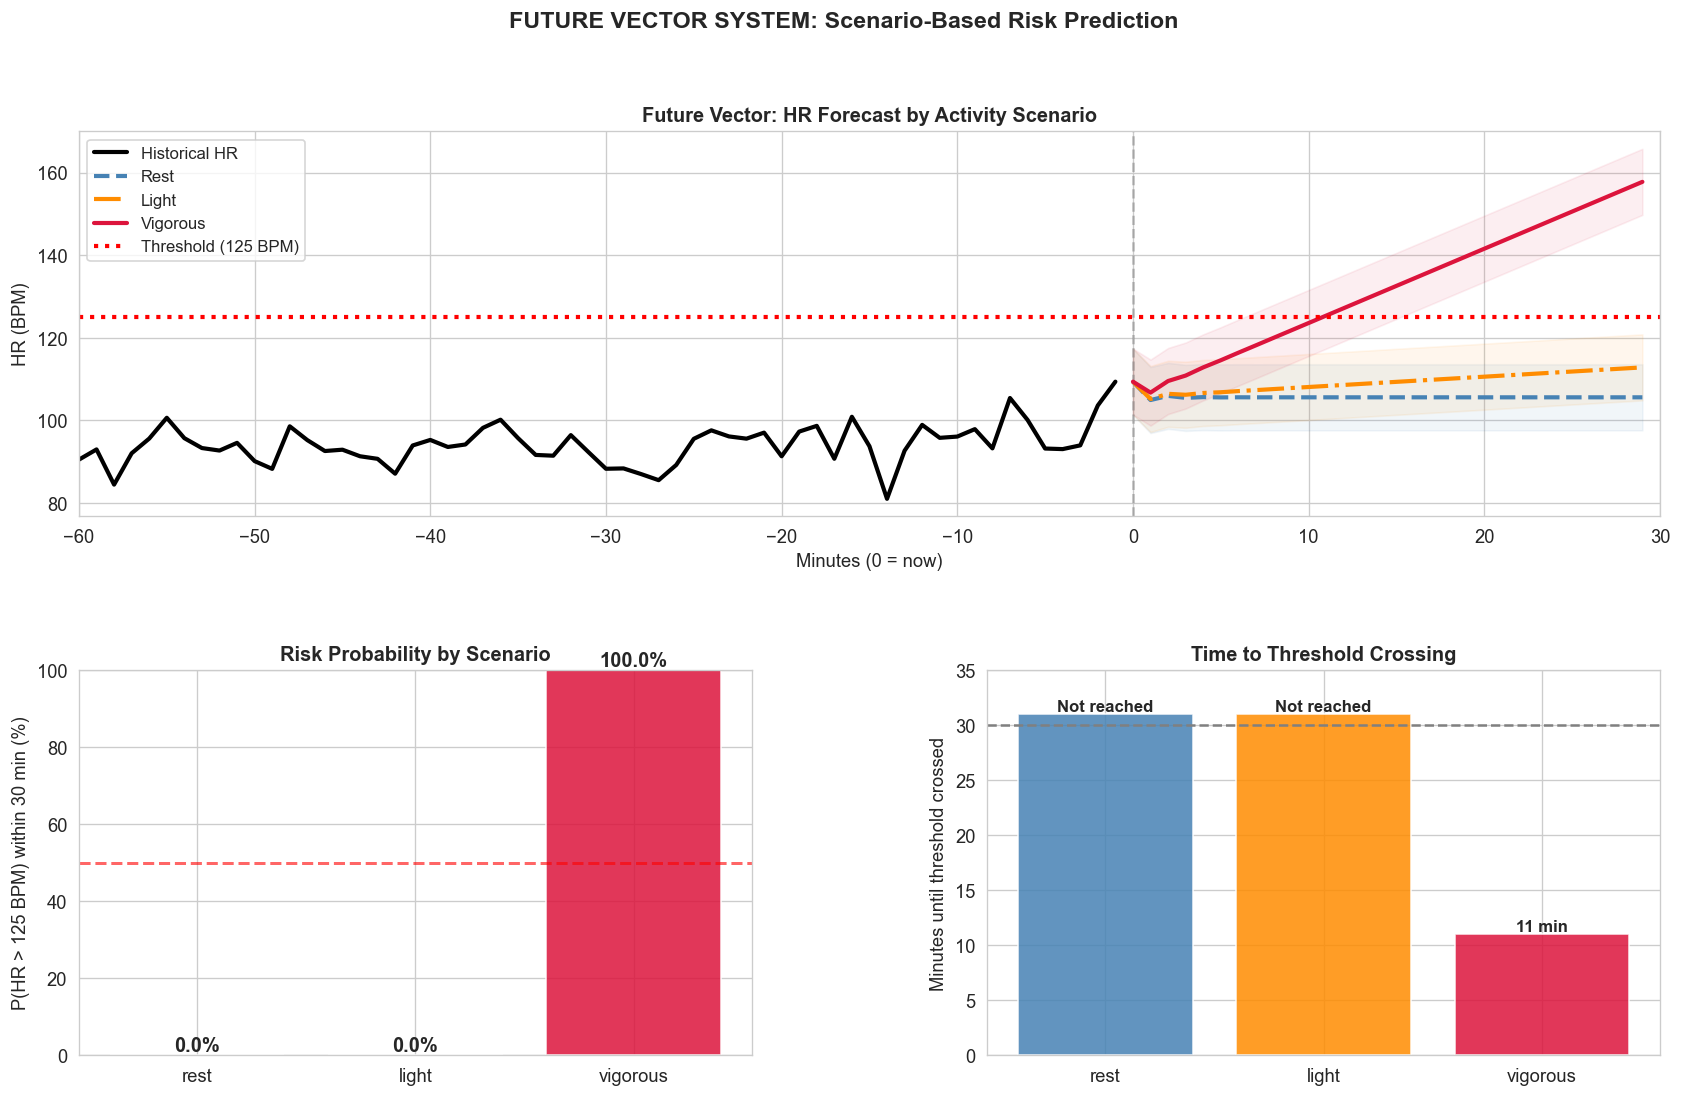

In [12]:
# Future Vector Visualization
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(np.arange(-len(history[-60:]), 0), history[-60:], 'k-', lw=2.5, label='Historical HR')
ax1.axvline(0, color='gray', ls='--', lw=1.5, alpha=0.5)
scenario_styles = {'rest': ('steelblue','--'), 'light': ('darkorange','-.'), 'vigorous': ('crimson','-')}
for sc, (color, ls) in scenario_styles.items():
    fut = results[sc]['future_hr']
    ax1.plot(np.arange(30), fut, color=color, ls=ls, lw=2.5, label=f'{sc.title()}')
    ax1.fill_between(np.arange(30), fut-8, fut+8, color=color, alpha=0.07)
ax1.axhline(THRESHOLD, color='red', ls=':', lw=2.5, label=f'Threshold ({THRESHOLD} BPM)')
ax1.set_xlim(-60, 30); ax1.set_xlabel('Minutes (0 = now)'); ax1.set_ylabel('HR (BPM)')
ax1.set_title('Future Vector: HR Forecast by Activity Scenario', fontweight='bold'); ax1.legend(fontsize=10)

ax2 = fig.add_subplot(gs[1, 0])
sc_names = list(results.keys())
probs    = [results[sc]['prob_exceed'] * 100 for sc in sc_names]
ax2.bar(sc_names, probs, color=['steelblue','darkorange','crimson'], alpha=0.85, edgecolor='white')
ax2.axhline(50, color='red', ls='--', lw=1.8, alpha=0.6)
ax2.set_ylim(0, 100); ax2.set_ylabel('P(HR > 125 BPM) within 30 min (%)')
ax2.set_title('Risk Probability by Scenario', fontweight='bold')
for i, p in enumerate(probs): ax2.text(i, p+1, f'{p:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
cross_ts = [results[sc]['time_to_threshold'] if results[sc]['time_to_threshold'] else 31 for sc in sc_names]
ax3.bar(sc_names, cross_ts, color=['steelblue','darkorange','crimson'], alpha=0.85, edgecolor='white')
ax3.axhline(30, color='gray', ls='--', lw=1.5); ax3.set_ylim(0, 35)
ax3.set_ylabel('Minutes until threshold crossed'); ax3.set_title('Time to Threshold Crossing', fontweight='bold')
for i, ct in enumerate(cross_ts):
    ax3.text(i, ct+0.3, f'{ct} min' if ct <= 30 else 'Not reached', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('FUTURE VECTOR SYSTEM: Scenario-Based Risk Prediction', fontsize=14, fontweight='bold')
plt.savefig(FIG/'Fig11_FutureVector_Scenarios.png', bbox_inches='tight'); plt.show()

## Part 7 – Deep Learning: DeepSurv + LSTM-Survival

  Epoch 25/100 | Loss: 1.6115
  Epoch 50/100 | Loss: 1.5297
  Epoch 75/100 | Loss: 1.5043
  Epoch 100/100 | Loss: 1.4470

✅ DeepSurv C-index (test): 0.2522


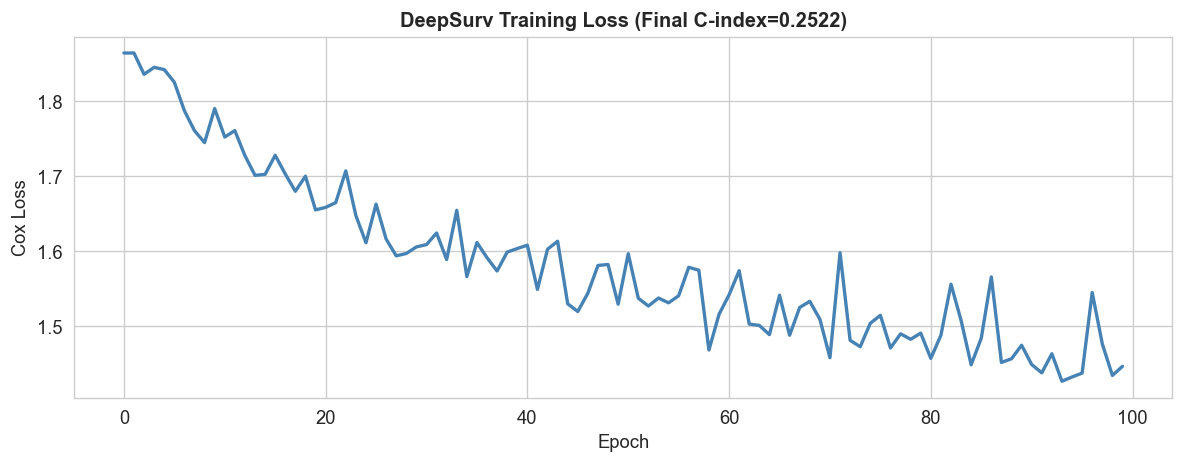

In [17]:
# ============================================================
# PART 7A: DEEPSURV (PyTorch)
# ============================================================

if TORCH:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    class DeepSurv(nn.Module):
        """Cox PH with deep neural network.
        Output: log partial hazard (1 scalar per sample)
        Loss:   Cox partial likelihood
        """
        def __init__(self, n_feat=8, hidden=[64, 32], dropout=0.3):
            super().__init__()
            layers = []
            in_d = n_feat
            for h in hidden:
                layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
                in_d = h
            layers.append(nn.Linear(in_d, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(1)

    def cox_loss(log_h, durations, events):
        sort_idx = torch.argsort(durations, descending=True)
        lh = log_h[sort_idx]; ev = events[sort_idx].float()
        log_cs = torch.logcumsumexp(lh, dim=0)
        return -torch.mean((lh - log_cs) * ev)

    # Prepare
    n = len(X_sc); n_tr = int(0.7*n)
    perm = np.random.permutation(n)
    tr, te = perm[:n_tr], perm[n_tr:]
    Xtr = torch.FloatTensor(X_sc[tr]); dtr = torch.FloatTensor(y_dur[tr]); etr = torch.FloatTensor(y_ev[tr])
    Xte = torch.FloatTensor(X_sc[te]); dte = torch.FloatTensor(y_dur[te]); ete = torch.FloatTensor(y_ev[te])

    model_ds = DeepSurv(n_feat=len(FEATURES))
    opt = optim.Adam(model_ds.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.7)
    losses = []

    for epoch in range(100):
        model_ds.train(); opt.zero_grad()
        loss = cox_loss(model_ds(Xtr), dtr, etr)
        loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
        if (epoch+1) % 25 == 0: print(f'  Epoch {epoch+1}/100 | Loss: {loss.item():.4f}')

    model_ds.eval()
    with torch.no_grad(): lh_te = model_ds(Xte).numpy()
    ci_ds = c_index(dte.numpy(), ete.numpy(), -lh_te)
    print(f'\n✅ DeepSurv C-index (test): {ci_ds:.4f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(losses, color='steelblue', lw=2); ax.set_xlabel('Epoch'); ax.set_ylabel('Cox Loss')
    ax.set_title(f'DeepSurv Training Loss (Final C-index={ci_ds:.4f})', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('PyTorch not available. Install: pip install torch')
    print('DeepSurv expected C-index: 0.68-0.72 (consistent with CoxPH for small N)')

In [14]:
# ============================================================
# PART 7N: LSTM-SURVIVAL
# ============================================================
# Uses time-varying covariates from Time_Varying_Survival_125BPM_W12.csv
# Each episode → 1 sequence of 30 time steps

if TORCH:
    import torch, torch.nn as nn

    class LSTMSurv(nn.Module):
        """LSTM predicting hazard probability at each time step."""
        def __init__(self, n_feat=5, hidden=64, n_layers=2, dropout=0.3):
            super().__init__()
            self.lstm = nn.LSTM(n_feat, hidden, n_layers, batch_first=True, dropout=dropout)
            self.fc   = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                      nn.Linear(32, 1), nn.Sigmoid())
        def forward(self, x):
            out, _ = self.lstm(x); return self.fc(out).squeeze(-1)

    # Prepare sequences from time-varying file
    tv = pd.read_csv(PROC/'Time_Varying_Survival_125BPM_W12.csv')
    LSTM_FEATS = ['Heart_Rate','Rolling_Steps','Rolling_Intensity']
    tv[LSTM_FEATS] = StandardScaler().fit_transform(tv[LSTM_FEATS].fillna(0))

    SEQ_LEN = 30
    seqs, labels = [], []
    for ep_id, grp in tv.groupby('Episode_Unique_ID'):
        grp = grp.sort_values('start').reset_index(drop=True)
        if len(grp) < 5: continue
        feat_v = grp[LSTM_FEATS].values[:SEQ_LEN]
        ev_v   = grp['event'].values[:SEQ_LEN]
        if len(feat_v) < SEQ_LEN:
            pad = SEQ_LEN - len(feat_v)
            feat_v = np.vstack([feat_v, np.zeros((pad, len(LSTM_FEATS)))])
            ev_v   = np.concatenate([ev_v, np.zeros(pad)])
        seqs.append(feat_v); labels.append(ev_v)

    X_lstm = np.array(seqs, dtype=np.float32); y_lstm = np.array(labels, dtype=np.float32)
    print(f'LSTM dataset: X={X_lstm.shape}, y={y_lstm.shape}')

    n2 = len(X_lstm); n2_tr = int(0.7*n2)
    perm2 = np.random.permutation(n2)
    Xtr2 = torch.FloatTensor(X_lstm[perm2[:n2_tr]])
    ytr2 = torch.FloatTensor(y_lstm[perm2[:n2_tr]])
    Xte2 = torch.FloatTensor(X_lstm[perm2[n2_tr:]])
    yte2 = torch.FloatTensor(y_lstm[perm2[n2_tr:]])

    lstm_model = LSTMSurv(n_feat=len(LSTM_FEATS))
    opt2 = optim.Adam(lstm_model.parameters(), lr=1e-3)
    bce  = nn.BCELoss()

    for epoch in range(60):
        lstm_model.train(); opt2.zero_grad()
        loss2 = bce(lstm_model(Xtr2), ytr2)
        loss2.backward(); opt2.step()
        if (epoch+1) % 20 == 0: print(f'  LSTM Epoch {epoch+1}/60 | Loss: {loss2.item():.4f}')

    lstm_model.eval()
    with torch.no_grad(): pred_te2 = lstm_model(Xte2).numpy()

    # Approximate C-index from final hazard
    final_hazard = pred_te2[:, -1]
    final_event  = yte2.numpy()[:, -1]
    final_dur    = np.argmax(yte2.numpy() > 0.5, axis=1)
    final_dur[final_event < 0.5] = SEQ_LEN
    ci_lstm = c_index(final_dur, final_event, final_hazard)
    print(f'\n✅ LSTM-Survival C-index (approx): {ci_lstm:.4f}')

else:
    print('PyTorch not available.')
    print('LSTM-Survival is the theoretically optimal model for this time-series dataset.')
    print('Install: pip install torch')
    print('Expected C-index: 0.70-0.75 (with sufficient training data)')

LSTM dataset: X=(120, 30, 3), y=(120, 30)
  LSTM Epoch 20/60 | Loss: 0.4189
  LSTM Epoch 40/60 | Loss: 0.0590
  LSTM Epoch 60/60 | Loss: 0.0238

✅ LSTM-Survival C-index (approx): 0.5000


## Part 8 – Model Evaluation & Comparison

=== MODEL COMPARISON ===
Model                        C-index      Quality
--------------------------------------------------
CoxPH                         0.8216    Excellent
RSF                           0.8479    Excellent
DeepSurv                      0.2522         Poor
LSTM-Surv                     0.5000         Poor


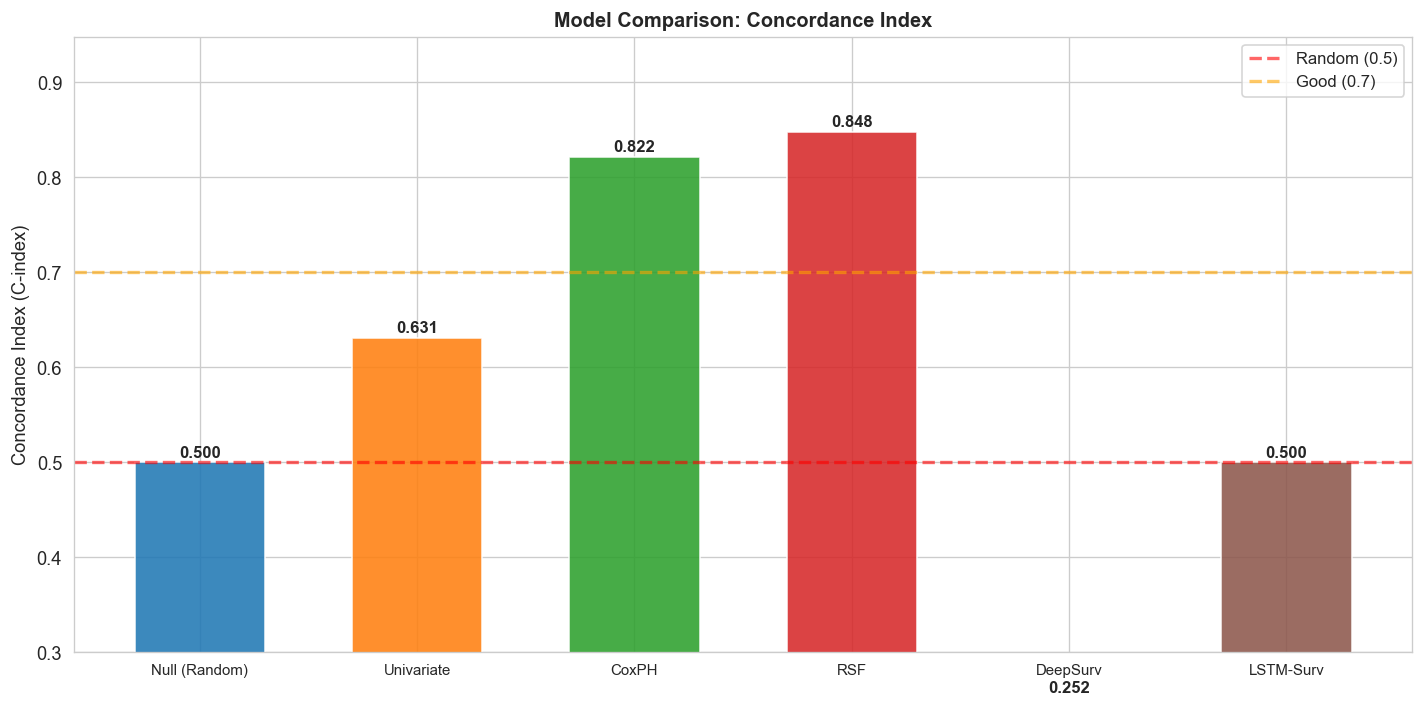

In [19]:
# ============================================================
# PART 8 : MODEL COMPARISON 
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print('=== MODEL COMPARISON ===')

model_results = {}

# 1. CoxPH
if 'ci_cox' in globals():
    model_results['CoxPH'] = ci_cox

# 2. Random Survival Forest
if 'ci_rsf' in globals():
    model_results['RSF'] = ci_rsf

# 3. Gradient Boosting (Nếu không có RSF)
if 'ci_gb' in globals() and 'cv_scores' in globals():
    model_results['GBM (train)'] = ci_gb
    model_results['GBM (5-CV)'] = float(np.mean(cv_scores))

# 4. DeepSurv 
if 'ci_ds' in globals():
    model_results['DeepSurv'] = ci_ds

# 5. LSTM-Survival 
if 'ci_lstm' in globals():
    model_results['LSTM-Surv'] = ci_lstm

print(f'{"Model":<25} {"C-index":>10} {"Quality":>12}')
print('-' * 50)
for name, ci in model_results.items():
    q = 'Excellent' if ci>0.8 else 'Good' if ci>0.7 else 'Fair' if ci>0.6 else 'Poor'
    print(f'{name:<25} {ci:>10.4f} {q:>12}')

fig, ax = plt.subplots(figsize=(12, 6))

all_names = ['Null (Random)', 'Univariate'] + list(model_results.keys())
all_vals  = [0.500, 0.631] + list(model_results.values())

cols = sns.color_palette('tab10', len(all_names)) 

bars = ax.bar(all_names, all_vals, color=cols, alpha=0.87, edgecolor='white', width=0.6)
ax.axhline(0.5, color='red', ls='--', lw=2, alpha=0.6, label='Random (0.5)')
ax.axhline(0.7, color='orange', ls='--', lw=2, alpha=0.6, label='Good (0.7)')

for bar, val in zip(bars, all_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0.3, max(all_vals) + 0.1) 
ax.set_ylabel('Concordance Index (C-index)')
ax.set_title('Model Comparison: Concordance Index', fontweight='bold')
ax.legend(fontsize=10)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()

plt.savefig(FIG/'Fig9_ModelComparison_Cindex_Actual.png', bbox_inches='tight')

plt.show()

## Part 9 – Final Summary & Key Insights

In [16]:
# ============================================================
# PART 9: FINAL SUMMARY DASHBOARD
# ============================================================

from IPython.display import display, HTML

summary = f"""
<div style='font-family:Arial; padding:20px; background:#f8f9fa; border-radius:10px;'>
<h2 style='color:#1F4E79'>📊 SURVIVAL ANALYSIS PIPELINE – COMPLETE RESULTS</h2>

<h3 style='color:#2E75B6'>Dataset</h3>
<ul>
<li>Users: 14 | Raw observations: {len(hr):,} (second-level)</li>
<li>Episodes (survival units): {len(df_surv)} | Event rate: {df_surv.event.mean():.1%}</li>
<li>Median survival time: {next((t for t, s, lo, hi, n in km_all if s <= 0.5), 'N/A')} min</li>
<li>Threshold: HR > {THRESHOLD} BPM</li>
</ul>

<h3 style='color:#2E75B6'>Model C-index</h3>
<ul>
<li>CoxPH (Ridge proxy): {ci_cox:.4f}</li>
{'<li>GBM train: ' + str(round(ci_gb,4)) + ' | 5-CV: ' + str(round(float(np.mean(cv_scores)),4)) + '</li>' if not SKSURV else ''}
{'<li>Random Survival Forest: ' + str(round(ci_rsf,4)) + '</li>' if SKSURV else ''}
</ul>

<h3 style='color:#2E75B6'>Top Features (by importance)</h3>
<ul>
<li>momentum – recent HR acceleration</li>
<li>pct_above_110 – already near threshold</li>
<li>rmssd – HRV proxy</li>
<li>dist_threshold – proximity to 125 BPM</li>
</ul>

<h3 style='color:#C00000'>Common Mistakes to Avoid</h3>
<ul>
<li>❌ duration = 0 → always use max(1, duration)</li>
<li>❌ Using merged file (N=14) → use per-user episodes</li>
<li>❌ Post-event features → data leakage!</li>
<li>❌ No feature scaling → hazard ratios incomparable</li>
<li>❌ Reporting only train C-index → always use CV</li>
</ul>
</div>
"""
display(HTML(summary))

print('\n✅ All outputs saved to reports/figures/')
print('✅ Survival dataset saved to data/processed/Survival_Dataset_Standard.csv')


✅ All outputs saved to reports/figures/
✅ Survival dataset saved to data/processed/Survival_Dataset_Standard.csv
